### Evaluate CV's

In [1]:
import os

# Change the current working directory to the parent directory
os.chdir("../")

# Verify the change
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II


In [2]:
%pip install -r ./requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


In [32]:
# Settings
from config.settings import PDF_FILE_PATH

# LLM and Vector Store setup
from src.vectorstore import setup_vectorstore
from src.ingestion import load_pdf_content, process_text_to_docs
from src.rag_engine import get_llm

# LangGraph
from langgraph.graph import START, StateGraph, END
# from langgraph.checkpoint.sqlite import SqliteSaver

# LangChain Core Messages
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_classic.chains import RetrievalQA

# Display
from IPython.display import display, Markdown
import json

# memory = SqliteSaver.from_conn_string(":memory:")

In [4]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

# Create an in-memory connection
conn = sqlite3.connect(":memory:", check_same_thread=False)

# Initialize the saver with the connection
memory = SqliteSaver(conn)

In [ ]:
class User:
    def __init__(self, name: str, path: str):
        self.name = name
        self.path = path

In [ ]:
user1 = User(name="Fabian", path="cvFS.pdf")
user2 = User(name="Milena", path="cvMilena.pdf")

In [5]:
# Ingesta controlada
text = load_pdf_content(PDF_FILE_PATH)
docs = process_text_to_docs(text, PDF_FILE_PATH)
# Vectorstore persistente
vectorstore = setup_vectorstore(documents=docs, reindex=True) # True solo la primera vez

Resolved path: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/tp2/ai_engineer_cv.pdf
Loading PDF from: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/tp2/ai_engineer_cv.pdf
Extracted 5042 characters from the PDF.
Resolved path: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/tp2/ai_engineer_cv.pdf


/Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/src/vectorstore.py:28: LangChainDeprecationWarning: The class `Pinecone` was deprecated in LangChain 0.0.3 and will be removed in 1.0.0. Use `PineconeVectorStore` instead.
  vectorstore = PineconeVectorStore(index=index, embedding=embeddings)


-> Subiendo batch 1...


In [6]:
# import openai
# # Core
# import os
# import re
# import io
# import logging
# import pathlib
# import sqlite3
# from typing import TypedDict, List

# # I/O and environment
# from dotenv import load_dotenv, find_dotenv
# from PyPDF2 import PdfReader
# from IPython.display import display, Markdown, Image

# from langchain_core.messages import SystemMessage, HumanMessage
# # LangChain
# from langchain.chains import RetrievalQA, LLMChain, StuffDocumentsChain
# from langchain.prompts import PromptTemplate
# from langchain.document_loaders import TextLoader
# from langchain.text_splitter import RecursiveCharacterTextSplitter
# from langchain.docstore.document import Document
# from langchain_core.messages import SystemMessage, HumanMessage
# from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# # Pinecone
# from pinecone import Pinecone, ServerlessSpec
# from langchain_pinecone import PineconeVectorStore

# # LangGraph
# from langgraph.graph import START, StateGraph, END
# from langgraph.checkpoint.sqlite import SqliteSaver

# # memory = SqliteSaver.from_conn_string(":memory:")

In [7]:
# # Load enviroment
# load_dotenv(find_dotenv())
# memory = SqliteSaver(sqlite3.connect(":memory:", check_same_thread=False))
# openai_api_key = os.getenv("OPENAI_API_KEY")
# pinecone_api_key = os.getenv('PINECONE')

# # Set the api keys
# openai.api_key =openai_api_key
# client = openai.OpenAI()

# MODEL_NAME = "gpt-4o-mini"  # Change to "gpt-3.5-turbo" if needed

In [8]:
# # Initialize OpenAIEmbedding from Langchain
# embeddings = OpenAIEmbeddings(openai_api_key=openai_api_key)

# pc = Pinecone(api_key=pinecone_api_key)

# index = pc.Index("quickstart")

# # Initialize Pinecone using Langchaing and sending the embedding
# pinecone_vectorstore = PineconeVectorStore(index=index, embedding=embeddings)

In [9]:
# ## Load the files
# from langchain.document_loaders import PyPDFLoader

# def load_pdf_texts_from_folder(folder_path: str):
#     all_docs = []
#     for filename in os.listdir(folder_path):
#         if filename.lower().endswith(".pdf"):
#             pdf_path = os.path.join(folder_path, filename)
#             loader = PyPDFLoader(pdf_path)
#             pages = loader.load()
#             all_docs.extend(pages)
            
#     return all_docs


# folder_path = pathlib.Path().resolve()
# docs_in_folder = load_pdf_texts_from_folder(folder_path)
# print(docs_in_folder)
# texts = [doc.page_content for doc in docs_in_folder]
# print(texts)


In [10]:

# doc_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100, separators=["\n\n", "\n", ".", " "])
# documents_for_evaluation = doc_splitter.split_documents(docs_in_folder)


# indices = [f"{'CV'}_{i+1}" for i in range(len(documents_for_evaluation))]

In [11]:
# # Upload the vector embedding to pinecone
# pinecone_vectorstore.add_documents(documents=documents_for_evaluation, ids=indices)

In [12]:
# The TypeDdict is imported from the typing module for defining a type of dictionary with specific values keys and typed values.
from typing import TypedDict, List
from typing_extensions import Annotated
from langchain_core.documents import Document
class AgentState(TypedDict):
    task:str
    question: str
    plan:str
    context: Annotated[List[Document], "accumulate"]
    answer: str
    content: Annotated[List[str], "accumulate"]

In [13]:
# ChatOpenAI.api_key = os.getenv("OPENAI_API_KEY")
# model = ChatOpenAI(
#     model=MODEL_NAME,
#     temperature=0,
#     max_tokens=None,
#     timeout=None,
#     max_retries=2,
# )


In [14]:
PLAN_PROMPT = """You are an expert writer tasked with drafting a high-level outline for evaluating CVs, curricula vitae, or resumes.
Write this outline for each of the CVs provided by the user. Provide a summary of the main characteristics of the given document.
You can read the CV from the output of the load_pdf_texts_from_folder function.
Maximum 100 words."""

In [ ]:
user1 = "Fabian"
user2 = "Milena"

In [ ]:
LLM_PROMPT_USER1 = """
You are an assistant that converts user goals into specific search queries to extract useful information from resumes. 
Only proceed if the candidate's name "{user1}" is explicitly mentioned in the {context}.

Generate 2 to 5 **short, specific** search queries related to evaluating candidates' skills, experience, and strengths.

Respond in this format:
{
  "queries": ["What are the candidate's main skills?", "What work experience is listed?", ...]
}

Call the generate function or agent or {context} to answer the questions.

Contexto: {context}
"""

In [ ]:
LLM_PROMPT_USER2 = """
You are an intelligent assistant tasked with transforming a user's goal into targeted search queries to help evaluate resume content. Your objective is to generate concise and specific queries that retrieve relevant details about a candidate's skills, experience, and strengths.

Proceed only if the candidate's name "{user2}" is explicitly mentioned in the {context}. If "{user2}" is not mentioned, respond with the following JSON exactly as shown:

{
  "error": "I cannot provide the evaluation because {user2} is not the candidate mentioned in the document."
}

If "{user2}" is present, generate 2 to 5 short, focused queries that could help evaluate her qualifications.

Respond only in the following JSON format:
{
  "queries": [
    "What are {user2}'s key technical skills?",
    "What job roles has {user2} previously held?",
    "Does {user2} have experience in data analysis?",
    "What certifications does {user2} have?",
    "What industries has {user2} worked in?"
  ]
}
"""


In [17]:
from pydantic import BaseModel
from typing import List

class Queries(BaseModel):
    queries: List[str]

In [18]:
# def plan_node(state: AgentState):
#     messages = [
#         SystemMessage(content=PLAN_PROMPT), 
#         HumanMessage(content=state['task'])
#     ]
#     response = model.invoke(messages)
#     return {"plan": response.content}

In [19]:
def plan_node(state):
    # 1. Instanciamos el modelo usando la configuración centralizada
    # Esto leerá LLM_PROVIDER de settings.py y devolverá ChatOpenAI o ChatGoogleGenerativeAI
    model = get_llm() 
    
    # 2. Construimos los mensajes (igual que antes)
    # Asegúrate de que PLAN_PROMPT esté definido como constante o impórtalo
    messages = [
        SystemMessage(content=PLAN_PROMPT), 
        HumanMessage(content=state['task'])
    ]
    
    # 3. Invocamos al modelo
    response = model.invoke(messages)
    
    # 4. Retornamos la actualización del estado
    return {"plan": response.content}

In [20]:
def retriever(state: AgentState):
     # Configuramos el vectorstore (sin reindexar)
     vs = setup_vectorstore(reindex=False)

     # Definimos la consulta
     query = state.get("question") or state.get("task")

     # Si el estado tiene un candidato objetivo, filtramos
     filter_dict = {}
     if "candidate_name" in state: 
          filter_dict = {"source": f"{state['candidate_name']}.pdf"}

     retriever = vs.as_retriever(search_kwargs={'k': 3, 'filter': filter_dict})
     relevant_docs = retriever.invoke(query)
     print(f"Docs recuperados para '{query}': {len(relevant_docs)}")

     return {"context": relevant_docs, "query":query}

In [21]:
def generate(state: AgentState):
    model = get_llm()
    
    context_docs = state.get("context", [])
    content_chunks = state.get("content", [])

    print("Context docs:", context_docs)
    print("Content chunks:", content_chunks)

    # Combine available content
    if context_docs:
        docs_content = "\n\n".join(texts.page_content for texts in context_docs if hasattr(texts, "page_content"))
    elif content_chunks:
        docs_content = "\n\n".join([str(chunk) for chunk in content_chunks])
    else:
        return {"answer": "No context or content available for answer generation."}

    # Get a safe fallback question string
    question = state.get('question') or state.get('task') or "Describe the main characteristics of the resumes."

    prompt_text = f"""Eres un asistente experto. Usa el siguiente contexto para responder a las preguntas.

Pregunta: {question}

Contexto:
{docs_content}

Respuesta:"""

    try:
        response = model.invoke([HumanMessage(content=prompt_text)])
        return {"answer": response.content}
    except Exception as e:
        print("Error during model invocation:", e)
        return {"answer": f"Error invoking model: {str(e)}"}

In [ ]:
def _run_evaluation(state: AgentState, system_prompt: str, source_filter: str = None):
    """
    Función auxiliar para ejecutar la evaluación de un candidato.
    
    Args:
        state: Estado del grafo.
        system_prompt: Prompt específico (USER1 o USER2).
        source_filter: Nombre del archivo PDF para filtrar (ej: 'cvFS.pdf'). 
                       Esto es CRÍTICO para evitar que un CV responda preguntas de otro.
    """
    # 1. Obtenemos el LLM configurado (OpenAI o Gemini)
    model = get_llm()
    
    # 2. Generación de Queries Estructuradas
    structured_llm = model.with_structured_output(Queries)
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=state.get('task', ''))
    ]

    try:
        queries = structured_llm.invoke(messages)
        print(f"Queries ({source_filter}):", queries)
    except Exception as e:
        return {"content": [], "error": f"Failed to generate queries: {e}"}

    if not queries or not getattr(queries, "queries", None):
        return {"content": [], "error": "No queries generated"}

    # 3. Configuración del Retriever
    # Usamos setup_vectorstore con reindex=False para eficiencia
    vs = setup_vectorstore(reindex=False)
    
    # 4. Filtro de Metadatos
    # Si source_filter es provisto, Pinecone solo buscará en ese documento.
    search_kwargs = {"k": 3}
    if source_filter:
        search_kwargs["filter"] = {"source": source_filter}

    # 5. Configuración de la cadena QA
    # Reutilizamos el mismo 'model' obtenido de get_llm()
    qa_chain = RetrievalQA.from_chain_type(
        llm=model, 
        chain_type="stuff",
        retriever=vs.as_retriever(search_type="similarity", search_kwargs=search_kwargs),
        return_source_documents=False
    )

    # 6. Ejecución de preguntas
    content = []
    for q in queries.queries:
        if not isinstance(q, str):
            continue
        try:
            result = qa_chain.invoke({"query": q})
            print(f"Answer: {result['result']}")
            content.append(result["result"])
        except Exception as e:
            # Manejo de casos donde no hay documentos (ej: user_name no encontrado)
            print(f"Error retrieving answer: {e}")
            content.append("No information found.")

    return {"content": content}

In [ ]:
def llm_user1_node(state: AgentState):
    return _run_evaluation(state, LLM_PROMPT_USER1, source_filter=user1.path)

def llm_user2_node(state: AgentState):
    return _run_evaluation(state, LLM_PROMPT_USER2, source_filter=user2.path)

In [24]:
def should_continue(state):
    return END

In [25]:
builder = StateGraph(AgentState)

In [26]:
builder.add_node("planner", plan_node)
builder.add_node("Evaluator1", llm_user1_node)
builder.add_node("Evaluator2", llm_user2_node)
builder.add_node("generate", generate)
builder.add_node("retriever", retriever)

builder.set_entry_point("planner")
builder.set_finish_point("Evaluator2")  
#builder.set_finish_point("Evaluator2")  

builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "generate")
builder.add_edge("generate", "Evaluator1")
builder.add_edge("Evaluator1", "Evaluator2")

In [27]:
builder.set_entry_point("planner")

In [28]:
builder.add_conditional_edges(
    "generate", 
    should_continue, 
    {END: END}
)


In [29]:
graph = builder.compile(checkpointer=memory)

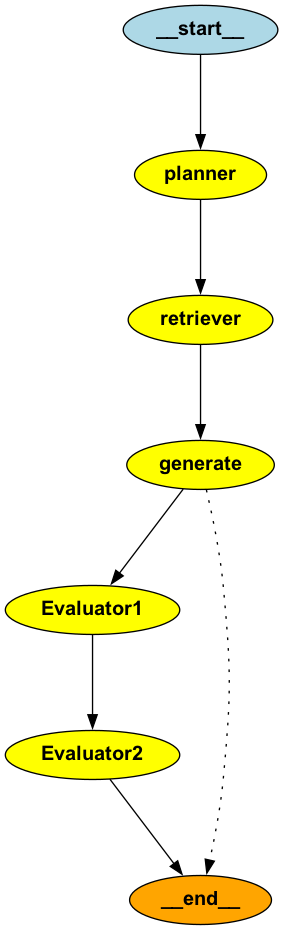

In [30]:
from IPython.display import Image

Image(graph.get_graph().draw_png())


In [35]:
# Simulación del stream y de las salidas
thread = {"configurable": {"thread_id": "1"}}

# Función para generar una salida más bonita
def print_pretty_output():
    initial_state = {
    "task": "Evalua cada uno de los cvs proporcionados. Indica las principales características del evaluado destacando sus fortalezas.",
    "content": []
}

    for s in graph.stream(initial_state, thread):
        display(Markdown(f"### Respuesta del sistema: \n\n{s}"))

# Llamar la función
print_pretty_output()


### Respuesta del sistema: 

{'planner': {'plan': 'Por favor, proporciona los CVs que deseas que evalúe. Una vez que me los hayas dado, los analizaré y te proporcionaré un resumen de sus características principales, destacando las fortalezas de cada candidato, dentro del límite de 100 palabras por CV.'}}

Docs recuperados para 'Evalua cada uno de los cvs proporcionados. Indica las principales características del evaluado destacando sus fortalezas.': 3


### Respuesta del sistema: 

{'retriever': {'context': [Document(id='doc_1', metadata={'source': 'ai_engineer_cv.pdf'}, page_content='cutting-edge\n \ntechnologies.\n \n➔\n \nCoding:\n \nPython\n \n(main)\n \n|\n \nJavaScript\n \n|\n \nHTML/CSS\n \n|\n \nVisual\n \nBasic\n \n➔\n \nLanguages:\n \nEnglish,\n \nSpanish,\n \nPortuguese\n \n(Fluent)\n|French\n \n(Proficient)\n|Italian,\n \nGerman\n \n(Basic)\n \n➔\n \nSoft\n \nskills:\n \nTeam\n \nleadership,\n \nagile\n \nstrategic\n \nplanning,\n \ndecision-making\n \nunder\n \npressure.\n \n★\n \nLed\n \nteams\n \nof\n \n20+\n \nmembers.\n \nClear\n \ncommunication\n \nof\n \nabstract\n \nconcepts.\n \n★\n \nStrategic\n \nanalysis\n \nand\n \nlong-term\n \nproject'), Document(id='doc_8', metadata={'source': 'ai_engineer_cv.pdf'}, page_content='Dec\n \n2023)\n:\n \nFounded\n \nB2B\n \nbrand\n \ndesign\n \nventure.\n \nManaged\n \nall\n \naspects\n \nof\n \noperations,\n \nincluding\n \nweb\n \ndevelopment,\n \nR/D,\n \nmarketing,\n \nsales,\n \nand\n \ncustomer\n \nservice.\n \n●\n \nNequevá\n \n(Since\n \nMay\n \n2021)\n:\n \nLed\n \nstrategic\n \nrebranding\n \nand\n \nrepositioning\n \nto\n \nColombian\n \nB2C\n \nmarket.\n \nData-driven\n \nstrategies\n \nfor\n \nmarketing\n \nand\n \ninvestment.\n \nRan\n \nad\n \ncampaigns\n \non\n \nFacebook.\n \n●\n \nImplemented\n \nDashboards\n \nfor\n \nsales,\n \ninventory\n \nand\n \nfinance.'), Document(id='doc_4', metadata={'source': 'ai_engineer_cv.pdf'}, page_content='data,\n \nand\n \nreal\n \nestate\n \ndata\n \n(via\n \nAPIs\n \n&\n \nScraping).\n \nEDUCATION\n \nMaster\n \nof\n \nScience\n \nin\n \nArtificial\n \nIntelligence\n \nUniversity\n \nof\n \nBuenos\n \nAires,\n \nFaculty\n \nof\n \nEngineering\n \n(UBA)\n \n2024-2026\n \n \n●\n \nFocus:\n \nDeep\n \nLearning,\n \nNLP,\n \nLLMs,\n \nComputer\n \nVision,\n \nTime\n \nSeries\n \n●\n \nThesis:\n \nComputer\n \nVision\n \n(YOLO\n \nModel)\n \nfor\n \nAgriculture\n \nwith\n \nAdecoagro\n \n(NYSE)\n \nBachelor\n \nof\n \nMusic\n \nPerformance\n \n&\n \nEducation\n \nAvellaneda\n \nSchool\n \nof\n \nPopular')]}}

Context docs: [Document(id='doc_1', metadata={'source': 'ai_engineer_cv.pdf'}, page_content='cutting-edge\n \ntechnologies.\n \n➔\n \nCoding:\n \nPython\n \n(main)\n \n|\n \nJavaScript\n \n|\n \nHTML/CSS\n \n|\n \nVisual\n \nBasic\n \n➔\n \nLanguages:\n \nEnglish,\n \nSpanish,\n \nPortuguese\n \n(Fluent)\n|French\n \n(Proficient)\n|Italian,\n \nGerman\n \n(Basic)\n \n➔\n \nSoft\n \nskills:\n \nTeam\n \nleadership,\n \nagile\n \nstrategic\n \nplanning,\n \ndecision-making\n \nunder\n \npressure.\n \n★\n \nLed\n \nteams\n \nof\n \n20+\n \nmembers.\n \nClear\n \ncommunication\n \nof\n \nabstract\n \nconcepts.\n \n★\n \nStrategic\n \nanalysis\n \nand\n \nlong-term\n \nproject'), Document(id='doc_8', metadata={'source': 'ai_engineer_cv.pdf'}, page_content='Dec\n \n2023)\n:\n \nFounded\n \nB2B\n \nbrand\n \ndesign\n \nventure.\n \nManaged\n \nall\n \naspects\n \nof\n \noperations,\n \nincluding\n \nweb\n \ndevelopment,\n \nR/D,\n \nmarketing,\n \nsales,\n \nand\n \ncustomer\n \nservice.\n \n

### Respuesta del sistema: 

{'generate': {'answer': 'Basándome en la información proporcionada, evalúo el CV de la siguiente manera:\n\n**Principales Características y Fortalezas del Evaluado:**\n\nEste CV presenta a un profesional con un perfil técnico sólido, habilidades de liderazgo demostradas y una fuerte orientación estratégica y emprendedora.\n\n**Fortalezas Clave:**\n\n*   **Sólida Base Técnica y Conocimiento de Tecnologías de Vanguardia:**\n    *   **Lenguajes de Programación:** Dominio de **Python** como lenguaje principal, complementado con **JavaScript**, **HTML/CSS** y **Visual Basic**. Esto indica versatilidad para el desarrollo web y de aplicaciones.\n    *   **Enfoque en Inteligencia Artificial:** La formación de Maestría en Inteligencia Artificial, con especializaciones en Deep Learning, NLP, LLMs, Computer Vision y Time Series, posiciona al candidato en la frontera de la tecnología actual.\n    *   **Proyectos de IA Específicos:** La tesis en "Computer Vision (YOLO Model) for Agriculture with Adecoagro" demuestra la aplicación práctica de conocimientos avanzados en un sector relevante y con una empresa de renombre.\n    *   **Manejo de Datos:** Experiencia en la recolección y procesamiento de datos, incluyendo la utilización de APIs y web scraping.\n\n*   **Liderazgo y Gestión de Equipos:**\n    *   **Experiencia Liderando Equipos Grandes:** Haber liderado equipos de **más de 20 miembros** es una fortaleza significativa, indicando capacidad para la gestión, delegación y coordinación de personal.\n    *   **Habilidades de Comunicación:** La capacidad para la **"Clear communication of abstract concepts"** es crucial para traducir ideas técnicas complejas a un lenguaje comprensible para diferentes audiencias.\n\n*   **Visión Estratégica y Planificación:**\n    *   **Agile Strategic Planning:** La mención de esta habilidad sugiere un enfoque moderno y adaptativo en la planificación de proyectos.\n    *   **Strategic analysis and long-term project:** Evidencia la capacidad de pensar a futuro y diseñar estrategias sostenibles.\n    *   **Rebranding y Reposicionamiento de Mercado:** La experiencia liderando el **"strategic rebranding and repositioning to Colombian B2C market"** demuestra una comprensión profunda de las dinámicas del mercado y la capacidad de implementar cambios significativos para optimizar el posicionamiento de una marca.\n\n*   **Capacidad Emprendedora y Gestión Integral de Negocios:**\n    *   **Fundación de un Emprendimiento Propio:** Haber fundado una **"B2B brand design venture"** es una muestra de iniciativa, visión de negocio y capacidad para asumir riesgos.\n    *   **Gestión Holística de Operaciones:** La responsabilidad sobre **"all aspects of operations, including web development, R/D, marketing, sales, and customer service"** revela una experiencia amplia y completa en la gestión de un negocio.\n\n*   **Habilidades Lingüísticas Avanzadas:**\n    *   **Dominio de Múltiples Idiomas:** La fluidez en **Inglés, Español y Portugués**, junto con un nivel avanzado de **Francés**, abre puertas a oportunidades internacionales y facilita la comunicación en diversos entornos globales.\n\n*   **Orientación a Datos y Métricas:**\n    *   **Data-driven strategies:** El uso de estrategias basadas en datos para marketing e inversión es un indicador de un enfoque analítico y orientado a resultados.\n    *   **Implementación de Dashboards:** La creación de **Dashboards for sales, inventory and finance** demuestra la capacidad de transformar datos brutos en información útil para la toma de decisiones y la monitorización del rendimiento.\n\n*   **Resiliencia y Toma de Decisiones:**\n    *   **Decision-making under pressure:** Esta habilidad es fundamental en entornos de alta exigencia y demuestra la capacidad de mantener la calma y la efectividad en situaciones críticas.\n\nEn resumen, el evaluado se destaca por ser un profesional altamente capacitado en tecnología, con una fuerte inclinación hacia la inteligencia artificial, complementado por una probada capacidad de liderazgo, visión estratégica y una mentalidad emprendedora. Sus habilidades multilingües y su enfoque en la toma de decisiones basada en datos lo convierten en un candidato muy valioso.'}}

### Respuesta del sistema: 

{'Evaluator1': {'content': []}}

### Respuesta del sistema: 

{'Evaluator2': {'content': []}}